<a href="https://colab.research.google.com/github/NIKUNJ-PROGRAMMER/PRE-PLACEMENT/blob/main/Capstone_Project(Covid_19).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#COVID-19 ANALYSIS AND FORECASTING PROJECT

In [17]:
import pandas as pd
import plotly.express as px
import plotly.graph_objects as go
from prophet import Prophet
import warnings
warnings.filterwarnings('ignore')

#Load Dataset

df=pd.read_csv('covid_19_clean_complete.csv')

print("Shape:",df.shape)
print("\nColumns:")
print(df.columns)

print("\nFirst 5 Rows:")
print(df.head())

#Data Preprocessing
df['Date'] = pd.to_datetime(df['Date'])

#Remove duplicates
df.drop_duplicates(inplace=True)

#Fill missing Province/State values
df['Province/State']= df['Province/State'].fillna('Unknown')

print("\nMissing Values:")
print(df.isnull().sum())

Shape: (49068, 10)

Columns:
Index(['Province/State', 'Country/Region', 'Lat', 'Long', 'Date', 'Confirmed',
       'Deaths', 'Recovered', 'Active', 'WHO Region'],
      dtype='object')

First 5 Rows:
  Province/State Country/Region       Lat       Long        Date  Confirmed  \
0            NaN    Afghanistan  33.93911  67.709953  2020-01-22          0   
1            NaN        Albania  41.15330  20.168300  2020-01-22          0   
2            NaN        Algeria  28.03390   1.659600  2020-01-22          0   
3            NaN        Andorra  42.50630   1.521800  2020-01-22          0   
4            NaN         Angola -11.20270  17.873900  2020-01-22          0   

   Deaths  Recovered  Active             WHO Region  
0       0          0       0  Eastern Mediterranean  
1       0          0       0                 Europe  
2       0          0       0                 Africa  
3       0          0       0                 Europe  
4       0          0       0                 Africa  



In [18]:
#Global Daily Statistics
global_daily=( df.groupby('Date')[['Confirmed',
                        'Deaths',
                        'Recovered',
                        'Active']]
    .sum()
    .reset_index()
)
print("\nGlobal Daily Data:")
print(global_daily.tail())


Global Daily Data:
          Date  Confirmed  Deaths  Recovered   Active
183 2020-07-23   15510481  633506    8710969  6166006
184 2020-07-24   15791645  639650    8939705  6212290
185 2020-07-25   16047190  644517    9158743  6243930
186 2020-07-26   16251796  648621    9293464  6309711
187 2020-07-27   16480485  654036    9468087  6358362


In [19]:
#Latest Global Statistics

latest=global_daily.iloc[-1]

print("\nLATEST GLOBAL FIGURES")
print("Confirmed : ",latest['Confirmed'])
print("Deaths    : ",latest['Deaths'])
print("Recovered : ",latest['Recovered'])
print("Active    : ",latest['Active'])

recovery_rate=(latest['Recovered']/latest['Confirmed'])*100
death_rate=(latest['Deaths']/latest['Confirmed'])*100
active_rate=(latest['Active']/latest['Confirmed'])*100

print("\nRecovery Rate: ",round(recovery_rate,2),"%")
print("Death Rate   : ",round(death_rate,2),"%")
print("Active Rate  : ",round(active_rate,2),"%")


LATEST GLOBAL FIGURES
Confirmed :  16480485
Deaths    :  654036
Recovered :  9468087
Active    :  6358362

Recovery Rate:  57.45 %
Death Rate   :  3.97 %
Active Rate  :  38.58 %


In [20]:
#PLOTLY VISUALIZATIONS

#Global Confirmed Trend
fig=px.line(
    global_daily,
    x='Date',
    y='Confirmed',
    title='Global Confirmed COVID-19 Cases Over Time'
)

fig.show()

#Global Recovered Trend
fig=px.line(
    global_daily,
    x='Date',
    y='Recovered',
    title='Global Recovered COVID-19 Cases Over Time'
)

fig.show()

#Global Death Trend
fig=px.line(
    global_daily,
    x='Date',
    y='Deaths',
    title='Global Death COVID-19 Cases Over Time'
)

fig.show()

#Active Cases Trend
fig=px.line(
    global_daily,
    x='Date',
    y='Active',
    title='Global Active COVID-19 Cases Over Time'
)

fig.show()

#TOP 10 COUNTRIES
latest_country = (
df[df['Date']==df['Date'].max()]
.groupby('Country/Region')[['Confirmed',
                            'Deaths',
                            'Recovered',
                            'Active']]
.sum()
.reset_index()
)

#TOP 10 CONFIRMED
top_confirmed=latest_country.nlargest(10,'Confirmed')

fig=px.bar(
    top_confirmed,
    x='Country/Region',
    y='Confirmed',
    title='Top 10 Countries by Confirmed Cases'
)

fig.show()

#Top 10 Deaths
top_deaths=latest_country.nlargest(10,'Deaths')

fig=px.bar(
    top_deaths,
    x='Country/Region',
    y='Deaths',
    title='Top 10 Countries by Deaths'
)

fig.show()

In [21]:
#PIE CHART OF GLOBAL STATUS

pie_df=pd.DataFrame({
    'Category':['Recovered','Deaths','Active'],
    'Count':[
        latest['Recovered'],
        latest['Deaths'],
        latest['Active']
      ]
})

fig=px.pie(
    pie_df,
    names='Category',
    values='Count',
    title='Global COVID-19 Cases',
)

fig.show()

In [22]:
#CHOROPLETH MAP

fig=px.choropleth(
    latest_country,
    locations='Country/Region',
    locationmode='country names',
    color='Confirmed',
    hover_name='Country/Region',
    title='Confirmed Cases by Country'
)

fig.show()

INFO:prophet:Disabling yearly seasonality. Run prophet with yearly_seasonality=True to override this.



NEXT 7 DAYS FORCAST:
            ds          yhat    yhat_lower    yhat_upper
188 2020-07-28  1.632169e+07  1.621807e+07  1.642812e+07
189 2020-07-29  1.653159e+07  1.642427e+07  1.664571e+07
190 2020-07-30  1.674570e+07  1.664265e+07  1.685135e+07
191 2020-07-31  1.696091e+07  1.685403e+07  1.707134e+07
192 2020-08-01  1.716864e+07  1.706058e+07  1.728928e+07
193 2020-08-02  1.736627e+07  1.725926e+07  1.747825e+07
194 2020-08-03  1.756092e+07  1.744928e+07  1.768512e+07


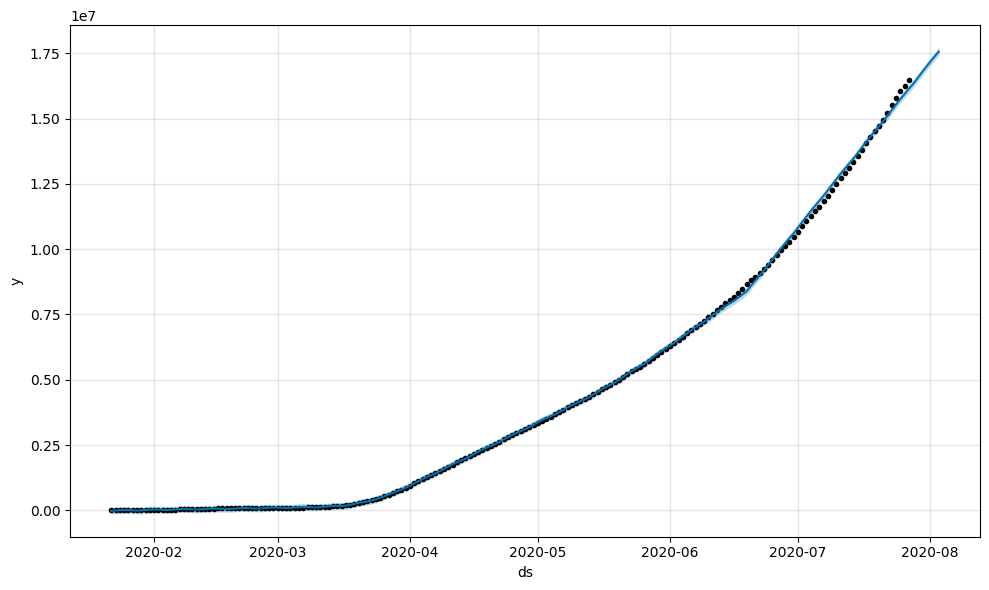

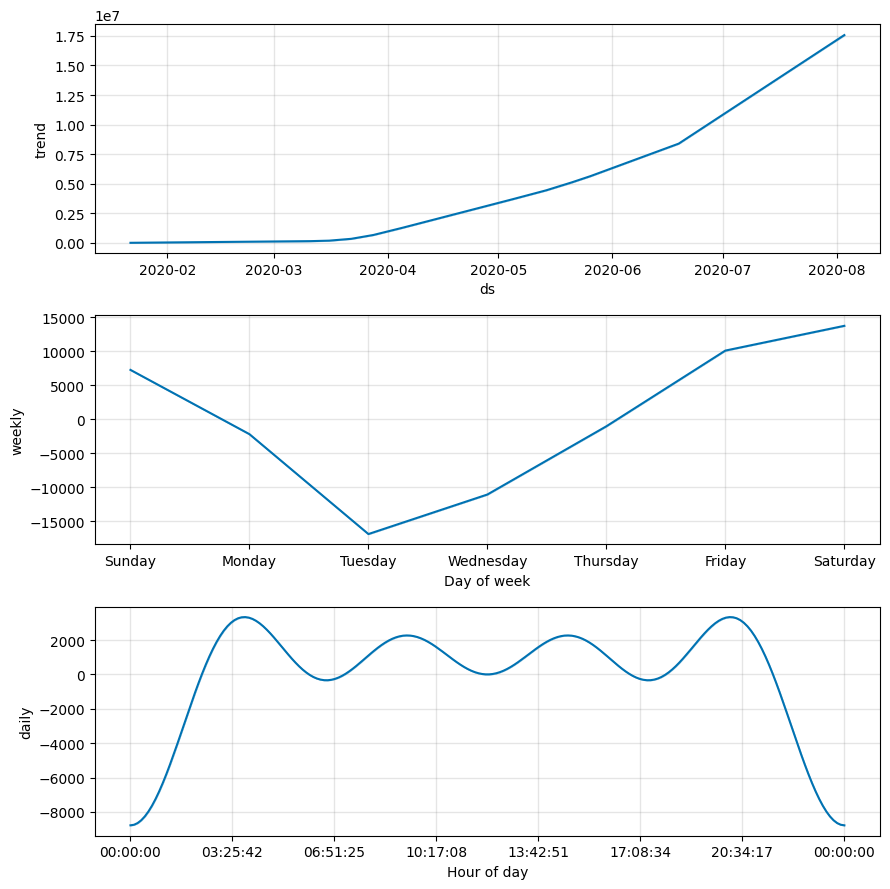

In [25]:
#PROPHET FORECASTING

#Prophet requires columns ds and y

forecast_df=global_daily[['Date','Confirmed']].copy()
forecast_df.columns=['ds','y']

model=Prophet(
    daily_seasonality=True
)
model.fit(forecast_df)

future=model.make_future_dataframe(periods=7)
forecast=model.predict(future)

print("\nNEXT 7 DAYS FORCAST:")

print(
    forecast[['ds',
              'yhat',
              'yhat_lower',
              'yhat_upper']].tail(7)
)

#Forecast Visualization

fig1=model.plot(forecast)
fig2=model.plot_components(forecast)

forecast_plot=forecast[['ds','yhat']].tail(30)
fig=go.Figure()
fig.add_trace(
    go.Scatter(
        x=global_daily['Date'],
        y=global_daily['Confirmed'],
        mode='lines',
        name='Actual Cases'
    )
)

fig.add_trace(
    go.Scatter(
        x=forecast_plot['ds'],
        y=forecast_plot['yhat'],
        mode='lines',
        name='Forecast'
    )
)

fig.update_layout(
    title='Actual vs Forecasted Confirmed Cases',
    xaxis_title='Date',
    yaxis_title='Confirmed Cases'
)

fig.show()

In [26]:
#Conclsuion

print('\nCONCLUSIONS')
print("""
1. Global confirmed COVID-19 cases increased steadily throughout the dataset period.
2. Recovery numbers also showed strong growth, indicating improvements in treatment and
patient outcomes.
3. Active cases remained high, suggesting ongoing transmission.
4. The countries with the highest confirmed cases and deaths contributed significantly to the
global burden.
5. Prophet forecasting predicts that confirmed cases are likely to continue increasing over the
next seven days if existing trends persist.
""")


CONCLUSIONS
 
1. Global confirmed COVID-19 cases increased steadily throughout the dataset period. 
2. Recovery numbers also showed strong growth, indicating improvements in treatment and 
patient outcomes. 
3. Active cases remained high, suggesting ongoing transmission. 
4. The countries with the highest confirmed cases and deaths contributed significantly to the 
global burden. 
5. Prophet forecasting predicts that confirmed cases are likely to continue increasing over the 
next seven days if existing trends persist. 

